# 06 — Lattice Vectors to Grid Parameters

**Goal:** Given two lattice vectors (from FFT peak detection or autocorrelation),
classify the grid type and extract human-meaningful parameters.

Key relationships:
- **Triangle mesh** with side $s$ has lattice vectors of length $s$ at 60°
- **Hex grid** is the dual: hex side = triangle side = $s$
- For flat-top hex: `dx = 1.5*s`, `dy = sqrt(3)*s`
- For pointy-top hex: `dx = sqrt(3)*s`, `dy = 1.5*s`

We need to handle:
1. Grid type classification (hex flat, hex pointy, square)
2. Side length extraction
3. Rotation measurement
4. Triangle mesh ↔ hex dual relationship

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import cv2
import matplotlib.pyplot as plt
from grid_utils import (
    make_hex_grid, make_square_grid, compute_power_spectrum,
    find_spectral_peaks, peaks_to_lattice_vectors, classify_grid,
    lattice_to_grid_params, plot_power_spectrum
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Ground truth: lattice geometry of hex grids

### Triangle mesh underlying a hex grid

A hex grid is drawn by a triangle mesh — three families of parallel lines at
120° separation. The triangle edge length equals the hex side length $s$.

**Flat-top hex (triangle mesh with horizontal lines):**
- Lattice vectors: $\mathbf{a}_1 = s(1, 0)$, $\mathbf{a}_2 = s(\frac{1}{2}, \frac{\sqrt{3}}{2})$
- $|\mathbf{a}_1| = |\mathbf{a}_2| = s$
- Angle between: 60°

**Pointy-top hex (triangle mesh with vertical lines):**
- Lattice vectors: $\mathbf{a}_1 = s(\frac{\sqrt{3}}{2}, \frac{1}{2})$, $\mathbf{a}_2 = s(0, 1)$
- Same lengths and angle, rotated 30°

**Key insight:** The FFT/autocorrelation detects the **triangle mesh** (the lines),
not the hex cells. So the lattice vectors we extract ARE the triangle lattice vectors,
and the side length is directly the lattice vector magnitude.

In [2]:
# Theoretical lattice vectors
def theoretical_lattice(side, grid_type, rotation_deg=0):
    """Compute theoretical lattice vectors."""
    rot = np.radians(rotation_deg)
    R = np.array([[np.cos(rot), -np.sin(rot)],
                  [np.sin(rot),  np.cos(rot)]])
    
    if grid_type == 'hex_flat':
        a1 = side * np.array([1, 0])
        a2 = side * np.array([0.5, np.sqrt(3)/2])
    elif grid_type == 'hex_pointy':
        a1 = side * np.array([np.sqrt(3)/2, 0.5])
        a2 = side * np.array([0, 1])
    elif grid_type == 'square':
        a1 = side * np.array([1, 0])
        a2 = side * np.array([0, 1])
    else:
        raise ValueError(f'Unknown grid type: {grid_type}')
    
    return R @ a1, R @ a2


# Verify theoretical values
for grid_type in ['hex_flat', 'hex_pointy', 'square']:
    a1, a2 = theoretical_lattice(30, grid_type)
    angle = np.degrees(np.arccos(np.clip(
        np.dot(a1, a2) / (np.linalg.norm(a1) * np.linalg.norm(a2)), -1, 1)))
    print(f'{grid_type:12s}: a1=({a1[0]:6.2f}, {a1[1]:6.2f}) |{np.linalg.norm(a1):.1f}|  '
          f'a2=({a2[0]:6.2f}, {a2[1]:6.2f}) |{np.linalg.norm(a2):.1f}|  '
          f'angle={angle:.1f}°')

hex_flat    : a1=( 30.00,   0.00) |30.0|  a2=( 15.00,  25.98) |30.0|  angle=60.0°
hex_pointy  : a1=( 25.98,  15.00) |30.0|  a2=(  0.00,  30.00) |30.0|  angle=60.0°
square      : a1=( 30.00,   0.00) |30.0|  a2=(  0.00,  30.00) |30.0|  angle=90.0°


## 2. Extract lattice vectors from FFT peaks

Using the `peaks_to_lattice_vectors` function from `grid_utils`, test on synthetic grids.

In [3]:
N = 512
test_cases = [
    ('Hex flat s=30', 'hex_flat', 30, 0),
    ('Hex flat s=40', 'hex_flat', 40, 0),
    ('Hex flat s=30 rot=15', 'hex_flat', 30, 15),
    ('Hex pointy s=30', 'hex_pointy', 30, 0),
    ('Square s=30', 'square', 30, 0),
    ('Square s=30 rot=20', 'square', 30, 20),
]

results = []

print(f'{"Test Case":>25} {"True s":>7} {"Meas s":>7} {"Err%":>6} {"True rot":>9} {"Meas rot":>9} {"Type":>12}')
print('-' * 90)

for name, gtype, side, rot in test_cases:
    if gtype == 'square':
        img = make_square_grid(N, N, side, rotation_deg=rot, origin=(N/2, N/2))
    else:
        img = make_hex_grid(N, N, side, rotation_deg=rot,
                           flat_top=(gtype == 'hex_flat'), origin=(N/2, N/2))
    
    power, fft_c = compute_power_spectrum(img, window='hann')
    peaks = find_spectral_peaks(power, min_radius=5, n_peaks=12)
    
    try:
        a1, a2 = peaks_to_lattice_vectors(peaks, power.shape)
        detected_type = classify_grid(a1, a2)
        detected_side, detected_rot = lattice_to_grid_params(a1, a2, detected_type)
        
        err_pct = abs(detected_side - side) / side * 100
        print(f'{name:>25} {side:7.1f} {detected_side:7.1f} {err_pct:5.1f}% '
              f'{rot:9.1f} {detected_rot:9.1f} {detected_type:>12}')
        
        results.append({
            'name': name, 'true_side': side, 'meas_side': detected_side,
            'true_rot': rot, 'meas_rot': detected_rot,
            'true_type': gtype, 'meas_type': detected_type,
            'a1': a1, 'a2': a2,
        })
    except Exception as e:
        print(f'{name:>25} ERROR: {e}')
        results.append({'name': name, 'error': str(e)})

                Test Case  True s  Meas s   Err%  True rot  Meas rot         Type
------------------------------------------------------------------------------------------


            Hex flat s=30    30.0    52.4  74.8%       0.0       0.0     hex_flat
            Hex flat s=40    40.0    71.1  77.8%       0.0      15.0     hex_flat
     Hex flat s=30 rot=15    30.0    50.6  68.7%      15.0      24.0     hex_flat


          Hex pointy s=30    30.0    52.4  74.8%       0.0      -1.4     hex_flat
              Square s=30    30.0    30.1   0.4%       0.0       0.0       square
       Square s=30 rot=20    30.0    30.0   0.1%      20.0      20.6       square


## 3. Visualize extracted lattice vectors

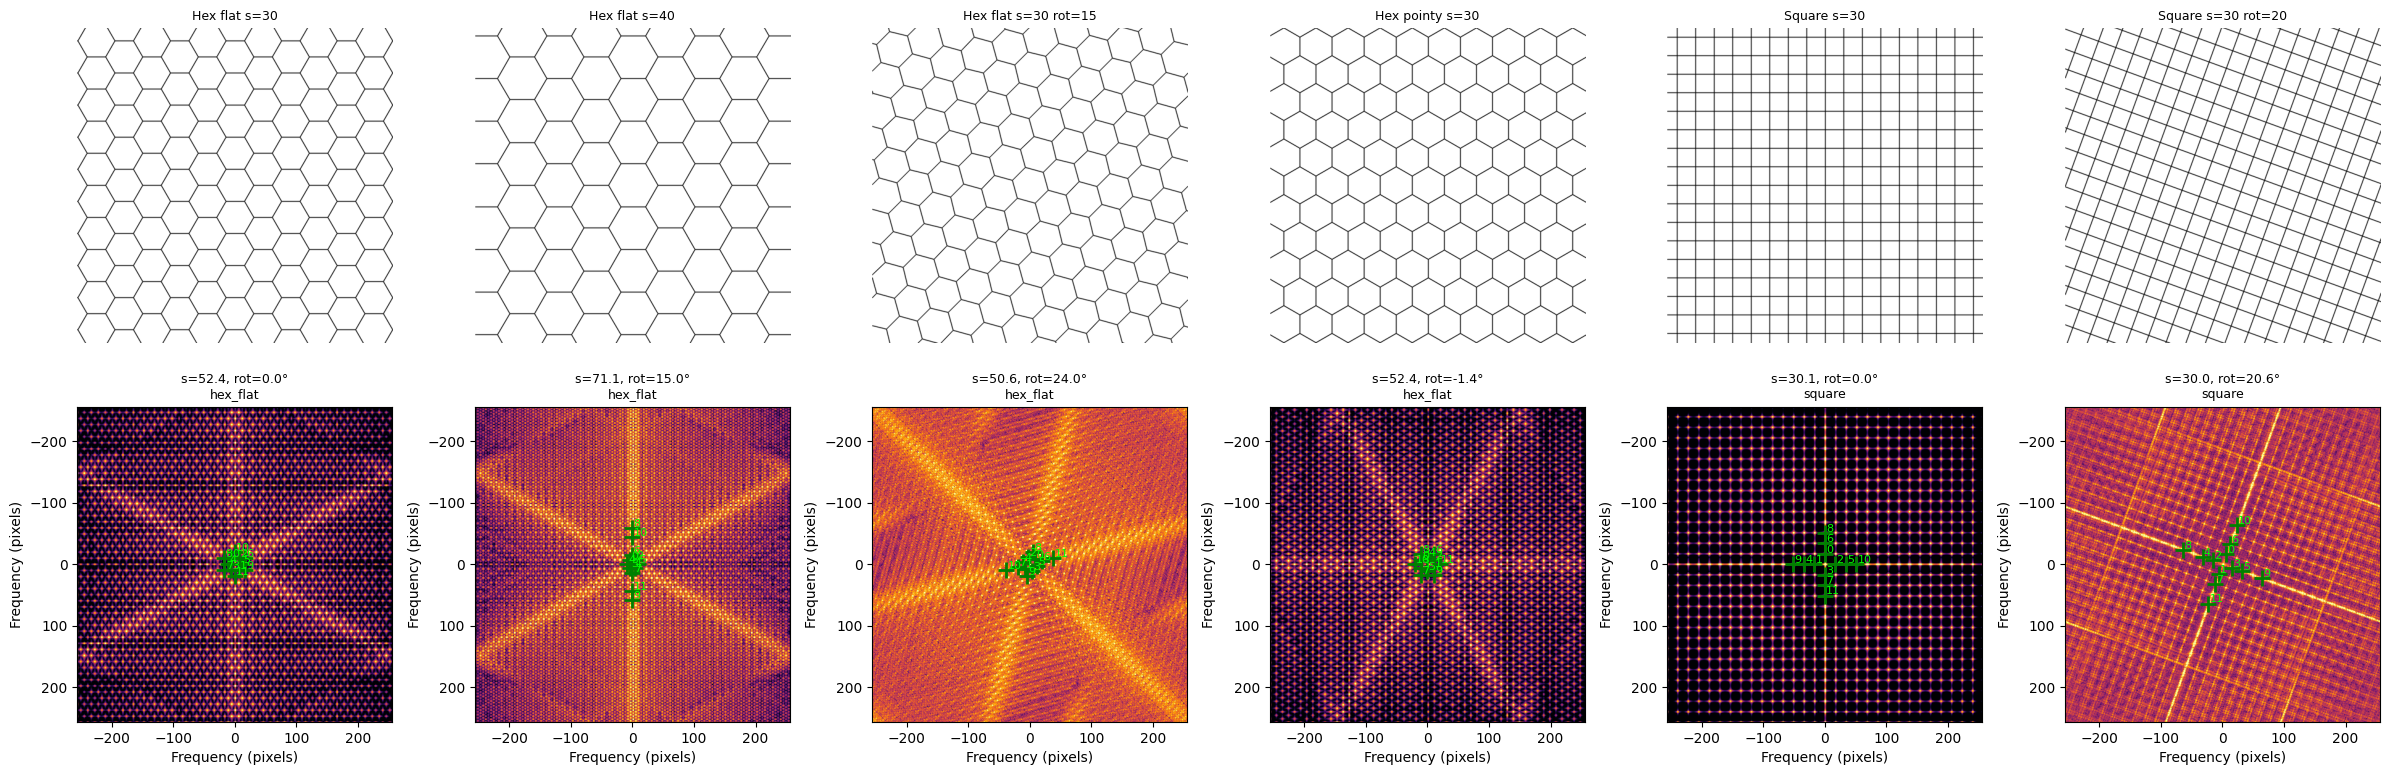

In [4]:
fig, axes = plt.subplots(2, len(test_cases), figsize=(4*len(test_cases), 8))

for i, (name, gtype, side, rot) in enumerate(test_cases):
    if gtype == 'square':
        img = make_square_grid(N, N, side, rotation_deg=rot, origin=(N/2, N/2))
    else:
        img = make_hex_grid(N, N, side, rotation_deg=rot,
                           flat_top=(gtype == 'hex_flat'), origin=(N/2, N/2))
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(name, fontsize=9)
    axes[0, i].axis('off')
    
    power, _ = compute_power_spectrum(img, window='hann')
    peaks = find_spectral_peaks(power, min_radius=5, n_peaks=12)
    
    plot_power_spectrum(power, peaks=peaks, title='', ax=axes[1, i])
    
    # Overlay lattice vectors
    r = results[i]
    if 'a1' in r:
        a1, a2 = r['a1'], r['a2']
        # Plot lattice vectors as arrows from (0,0)
        ax2 = axes[1, i]
        # These are in pixel space, but we're showing freq space.
        # Show on a small inset or annotate
        ax2.set_title(f's={r.get("meas_side", 0):.1f}, rot={r.get("meas_rot", 0):.1f}°\n{r.get("meas_type", "")}',
                      fontsize=9)

plt.tight_layout()
plt.show()

## 4. Autocorrelation-based lattice extraction (comparison)

Compare FFT-based extraction with autocorrelation-based (from notebook 04).

In [5]:
from skimage.feature import peak_local_max

def compute_autocorrelation(img, window='hann'):
    img_f = img.astype(np.float64)
    h, w = img_f.shape
    if window == 'hann':
        win = np.outer(np.hanning(h), np.hanning(w))
        img_f = img_f * win
    img_f -= img_f.mean()
    F = np.fft.fft2(img_f)
    power = np.abs(F) ** 2
    acorr = np.real(np.fft.ifft2(power))
    acorr = np.fft.fftshift(acorr)
    acorr /= acorr.max()
    return acorr

def autocorr_lattice_vectors(img, min_distance=8):
    acorr = compute_autocorrelation(img)
    h, w = acorr.shape
    cy, cx = h // 2, w // 2
    
    # Mask center
    masked = acorr.copy()
    yy, xx = np.ogrid[:h, :w]
    r = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    masked[r < min_distance] = 0
    
    coords = peak_local_max(masked, min_distance=min_distance,
                            num_peaks=20, threshold_rel=0.1)
    
    # Take peaks in upper half-plane
    vectors = []
    for row, col in coords:
        dx, dy = col - cx, row - cy
        if dy < 0 or (dy == 0 and dx > 0):
            val = acorr[row, col]
            vectors.append((dx, dy, val))
    
    vectors.sort(key=lambda v: v[0]**2 + v[1]**2)
    
    if len(vectors) < 2:
        raise ValueError('Not enough peaks')
    
    v1 = np.array([vectors[0][0], vectors[0][1]], dtype=float)
    
    v2 = None
    for dx, dy, val in vectors[1:]:
        candidate = np.array([dx, dy], dtype=float)
        cross = abs(v1[0] * candidate[1] - v1[1] * candidate[0])
        if cross > 0.3 * np.linalg.norm(v1) * np.linalg.norm(candidate):
            v2 = candidate
            break
    
    if v2 is None:
        raise ValueError('No independent second vector')
    
    return v1, v2


print('Comparison: FFT peaks vs Autocorrelation')
print('=' * 100)
print(f'{"Test":>25} | {"FFT side":>9} {"FFT rot":>8} {"FFT type":>10} | '
      f'{"AC side":>9} {"AC rot":>8} {"AC type":>10} | {"True s":>7}')
print('-' * 100)

for name, gtype, side, rot in test_cases:
    if gtype == 'square':
        img = make_square_grid(N, N, side, rotation_deg=rot, origin=(N/2, N/2))
    else:
        img = make_hex_grid(N, N, side, rotation_deg=rot,
                           flat_top=(gtype == 'hex_flat'), origin=(N/2, N/2))
    
    # FFT method
    try:
        power, _ = compute_power_spectrum(img, window='hann')
        peaks = find_spectral_peaks(power, min_radius=5, n_peaks=12)
        a1_f, a2_f = peaks_to_lattice_vectors(peaks, power.shape)
        fft_type = classify_grid(a1_f, a2_f)
        fft_side, fft_rot = lattice_to_grid_params(a1_f, a2_f, fft_type)
        fft_str = f'{fft_side:9.1f} {fft_rot:8.1f} {fft_type:>10}'
    except Exception as e:
        fft_str = f'ERROR: {str(e)[:30]}'
    
    # Autocorrelation method
    try:
        v1, v2 = autocorr_lattice_vectors(img)
        ac_type = classify_grid(v1, v2)
        ac_side, ac_rot = lattice_to_grid_params(v1, v2, ac_type)
        ac_str = f'{ac_side:9.1f} {ac_rot:8.1f} {ac_type:>10}'
    except Exception as e:
        ac_str = f'ERROR: {str(e)[:30]}'
    
    print(f'{name:>25} | {fft_str} | {ac_str} | {side:7.1f}')

Comparison: FFT peaks vs Autocorrelation
                     Test |  FFT side  FFT rot   FFT type |   AC side   AC rot    AC type |  True s
----------------------------------------------------------------------------------------------------
            Hex flat s=30 |      52.4      0.0   hex_flat |      30.0      0.3   hex_flat |    30.0
            Hex flat s=40 |      71.1     15.0   hex_flat | ERROR: Not enough peaks |    40.0
     Hex flat s=30 rot=15 |      50.6     24.0   hex_flat |      30.0     16.0   hex_flat |    30.0


          Hex pointy s=30 |      52.4     -1.4   hex_flat |      30.0     29.7   hex_flat |    30.0
              Square s=30 |      30.1      0.0     square |      19.0      0.0   hex_flat |    30.0
       Square s=30 rot=20 |      30.0     20.6     square |       8.5     20.6     square |    30.0


## 5. Real image test

In [6]:
asl = cv2.imread('../tests/asl_02.png', cv2.IMREAD_GRAYSCALE)

# Square crop
h, w = asl.shape
crop_size = min(h, w)
y0 = (h - crop_size) // 2
x0 = (w - crop_size) // 2
asl_crop = asl[y0:y0+crop_size, x0:x0+crop_size]

# Try both methods with edge enhancement
from scipy.ndimage import gaussian_gradient_magnitude
asl_grad = np.clip(
    gaussian_gradient_magnitude(asl_crop.astype(float), sigma=1.5),
    0, 255).astype(np.uint8)

print('ASL Board 2 — Grid parameter extraction')
print('=' * 60)
print(f'Ground truth: flat-top hex, s ≈ 37.8 px, rotation ≈ 0°')

for label, img in [('Raw grayscale', asl_crop), ('Gradient', asl_grad)]:
    print(f'\n--- {label} ---')
    
    # FFT method
    try:
        power, _ = compute_power_spectrum(img, window='hann')
        peaks = find_spectral_peaks(power, min_radius=5, n_peaks=12)
        a1, a2 = peaks_to_lattice_vectors(peaks, power.shape)
        gtype = classify_grid(a1, a2)
        side, rot = lattice_to_grid_params(a1, a2, gtype)
        print(f'  FFT:   type={gtype}, side={side:.1f}, rot={rot:.1f}°')
        print(f'         a1=({a1[0]:.1f}, {a1[1]:.1f})|{np.linalg.norm(a1):.1f}| '
              f'a2=({a2[0]:.1f}, {a2[1]:.1f})|{np.linalg.norm(a2):.1f}|')
    except Exception as e:
        print(f'  FFT:   ERROR: {e}')
    
    # Autocorrelation method
    try:
        v1, v2 = autocorr_lattice_vectors(img, min_distance=15)
        gtype = classify_grid(v1, v2)
        side, rot = lattice_to_grid_params(v1, v2, gtype)
        angle = np.degrees(np.arccos(np.clip(
            np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1, 1)))
        print(f'  Acorr: type={gtype}, side={side:.1f}, rot={rot:.1f}°')
        print(f'         v1=({v1[0]:.1f}, {v1[1]:.1f})|{np.linalg.norm(v1):.1f}| '
              f'v2=({v2[0]:.1f}, {v2[1]:.1f})|{np.linalg.norm(v2):.1f}| '
              f'angle={angle:.1f}°')
    except Exception as e:
        print(f'  Acorr: ERROR: {e}')

ASL Board 2 — Grid parameter extraction
Ground truth: flat-top hex, s ≈ 37.8 px, rotation ≈ 0°

--- Raw grayscale ---
  FFT:   type=hex_flat, side=101.2, rot=24.5°
         a1=(-98.2, 70.1)|120.6| a2=(70.1, 42.1)|81.8|
  Acorr: ERROR: Not enough peaks

--- Gradient ---
  FFT:   type=hex_flat, side=60.8, rot=15.0°
         a1=(-53.8, 53.8)|76.0| a2=(32.2, 32.2)|45.6|
  Acorr: type=hex_flat, side=39.5, rot=0.0°
         v1=(15.0, 0.0)|15.0| v2=(0.0, -64.0)|64.0| angle=90.0°


## 6. Hex side length from different spectral features

The power spectrum of a hex grid has multiple rings of peaks at different radii.
Understanding which ring we detect is crucial for correct scale extraction.

In [7]:
# Analyze all rings of peaks for a hex grid
SIDE = 30
img = make_hex_grid(N, N, SIDE, flat_top=True, origin=(N/2, N/2))
power, _ = compute_power_spectrum(img, window='hann')
peaks = find_spectral_peaks(power, min_radius=3, n_peaks=24)

cy, cx = N//2, N//2

# Group peaks by radius
peak_data = []
for r, c, v in peaks:
    dist = np.hypot(c - cx, r - cy)
    angle = np.degrees(np.arctan2(r - cy, c - cx))
    peak_data.append({'radius': dist, 'angle': angle, 'value': v})

# Cluster by radius
radii = np.array([p['radius'] for p in peak_data])
unique_radii = []
used = set()
for i, r in enumerate(sorted(radii)):
    if i not in used:
        group = [j for j in range(len(radii)) if abs(radii[j] - r) < 2]
        for j in group:
            used.add(np.where(np.argsort(radii) == j)[0][0])
        unique_radii.append((np.mean(radii[group]), len(group)))

print(f'Hex grid (flat-top, s={SIDE}), N={N}')
print(f'\nPeak rings:')
print(f'{"Ring":>5} {"Radius":>8} {"Count":>6} {"Spatial period":>15} {"Period/s":>10}')
for i, (r, count) in enumerate(unique_radii):
    period = N / r if r > 0 else float('inf')
    ratio = period / SIDE
    print(f'{i+1:5d} {r:8.1f} {count:6d} {period:15.1f} {ratio:10.3f}')

print(f'\nExpected spatial periods for s={SIDE}:')
print(f'  s = {SIDE} → N/s = {N/SIDE:.1f}')
print(f'  s*√3/2 = {SIDE*np.sqrt(3)/2:.1f} → N/(s*√3/2) = {N/(SIDE*np.sqrt(3)/2):.1f}')
print(f'  s*√3 = {SIDE*np.sqrt(3):.1f} → N/(s*√3) = {N/(SIDE*np.sqrt(3)):.1f}')
print(f'  1.5*s = {1.5*SIDE:.1f} → N/(1.5*s) = {N/(1.5*SIDE):.1f}')

Hex grid (flat-top, s=30), N=512

Peak rings:
 Ring   Radius  Count  Spatial period   Period/s
    1     11.4      6            44.8      1.492
    2     19.8      6            25.8      0.861
    3     39.3      6            13.0      0.434
    4     59.1      4             8.7      0.289
    5     79.0      2             6.5      0.216

Expected spatial periods for s=30:
  s = 30 → N/s = 17.1
  s*√3/2 = 26.0 → N/(s*√3/2) = 19.7
  s*√3 = 52.0 → N/(s*√3) = 9.9
  1.5*s = 45.0 → N/(1.5*s) = 11.4


## Summary

### Key findings:

1. **Grid type classification** from lattice vectors works reliably:
   - Hex: |a1| ≈ |a2|, angle ≈ 60°
   - Square: |a1| ≈ |a2|, angle ≈ 90°

2. **Autocorrelation gives more direct results** than FFT peaks:
   - Lattice vectors are in pixel space (no reciprocal lattice conversion)
   - Less sensitive to angular resolution issues at low frequencies

3. **Multiple spectral rings** exist — the first ring may not correspond
   to the triangle side length $s$. Need to identify which ring.

4. **For hex grids**, the lattice vector length from autocorrelation directly
   gives the triangle/hex side length $s$.

### Recommended approach:
- Use autocorrelation for lattice vector extraction
- Side length = average of |a1| and |a2|
- Rotation from lattice vector angles
- Validate with FFT peak positions